In [27]:
!pip install lifelines

In [28]:
import pandas as pd
df = pd.read_csv('model_input.csv')
print(df.shape)
df.head()


(15868, 20)


,season,match_date,team,manager,manager_start_date,points,points_last_5,points_last_10,matches_into_tenure_so_far,tenure_days_so_far,league_position_before_match,points_to_date,gd_to_date,expectation_baseline,expectation_source,expectation_gap,event_observed,event_type,tenure_total_duration_days,tenure_end_date
0,506,03/01/2006,Man United,Alex Ferguson,06/11/1986,1,13.0,26.0,20,6998,1,44,23,NaN,no_prior_data,NaN,0,end_of_season,9704,01/06/2013
1,506,06/11/2005,Man United,Alex Ferguson,06/11/1986,3,7.0,18.0,10,6940,2,18,4,NaN,no_prior_data,NaN,0,end_of_season,9704,01/06/2013
2,506,17/12/2005,Man United,Alex Ferguson,06/11/1986,3,13.0,23.0,16,6981,1,34,15,NaN,no_prior_data,NaN,0,end_of_season,9704,01/06/2013
3,506,29/03/2006,Man United,Alex Ferguson,06/11/1986,3,15.0,22.0,30,7083,1,66,32,NaN,no_prior_data,NaN,0,end_of_season,9704,01/06/2013
4,506,29/10/2005,Man United,Alex Ferguson,06/11/1986,0,8.0,18.0,9,6932,5,18,7,NaN,no_prior_data,NaN,0,end_of_season,9704,01/06/2013


In [29]:
df['match_date'] = pd.to_datetime(df['match_date'], format='%d/%m/%Y')


In [30]:
survival_df = (
    df.sort_values('match_date')
      .groupby(['manager', 'team', 'manager_start_date'])
      .last()
      .reset_index()
)

survival_df = survival_df[[
    'manager', 'team', 'manager_start_date',
    'points_last_5', 'points_last_10',
    'league_position_before_match',
    'expectation_gap',
    'tenure_total_duration_days',
    'event_observed', 'event_type'
]]

print(survival_df.shape)
survival_df.head()

(283, 10)


,manager,team,manager_start_date,points_last_5,points_last_10,league_position_before_match,expectation_gap,tenure_total_duration_days,event_observed,event_type
0,Aidy Boothroyd,Watford,29/03/2005,7.0,8.0,20,-3.0,1315,0,non_pl_departure
1,Aitor Karanka,Middlesbrough,13/11/2013,2.0,7.0,12,5.0,1219,1,sacked
2,Alain Perrin,Portsmouth,07/04/2005,5.0,10.0,10,NaN,231,1,sacked
3,Alan Curbishley,Charlton,24/07/1991,4.0,12.0,12,NaN,5402,0,end_of_season
4,Alan Curbishley,West Ham,13/12/2006,5.0,9.0,9,1.0,630,0,mid_season_not_sacked


In [31]:
# Check for managers/clubs with multiple suspiciously-close start dates
# (could indicate the same real tenure getting split into two)
check = df.groupby(['manager', 'team'])['manager_start_date'].nunique().reset_index()
check = check[check['manager_start_date'] > 1]
print(check.shape)
check

(7, 3)


,manager,team,manager_start_date
48,Chris Wilder,Sheffield United,2
58,David Moyes,Everton,2
61,David Moyes,West Ham,2
110,José Mourinho,Chelsea,2
181,Paul Heckingbottom,Sheffield United,2
191,Quique Sánchez Flores,Watford,2
210,Roy Hodgson,Crystal Palace,2


In [32]:
survival_df[['tenure_total_duration_days', 'event_observed', 'expectation_gap']].isnull().sum()

,0
tenure_total_duration_days,0
event_observed,0
expectation_gap,8


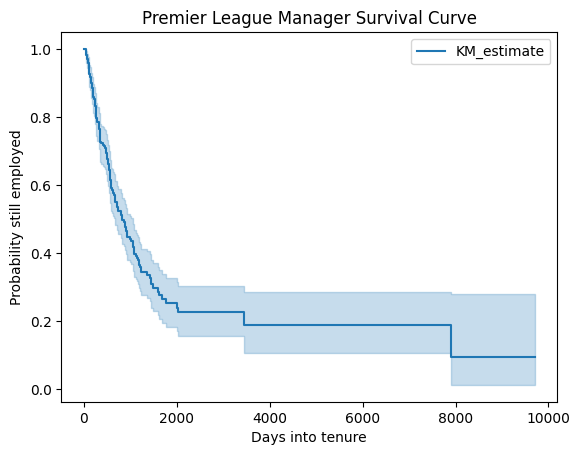

Median survival time: 827.0 days


In [33]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()
kmf.fit(durations=survival_df['tenure_total_duration_days'],
        event_observed=survival_df['event_observed'])

kmf.plot_survival_function()
plt.title('Premier League Manager Survival Curve')
plt.xlabel('Days into tenure')
plt.ylabel('Probability still employed')
plt.show()

print(f"Median survival time: {kmf.median_survival_time_} days")

In [34]:
from lifelines import CoxPHFitter

cox_df = survival_df.dropna(subset=['expectation_gap', 'points_last_5']).copy()

cox_df = cox_df[[
    'tenure_total_duration_days', 'event_observed',
    'points_last_5', 'expectation_gap', 'league_position_before_match'
]]

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='tenure_total_duration_days', event_col='event_observed')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 273 total observations, 124 right-censored observations>
             duration col = 'tenure_total_duration_days'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 273
number of events observed = 149
   partial log-likelihood = -684.48
         time fit was run = 2026-09-16 08:22:09 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
points_last_5                -0.21      0.81      0.04           -0.28           -0.14                0.75                0.87
expectation_gap               0.02      1.02      0.02           -0.02            0.06                0.98                1.06
league_position_before_match -0.06      0.94      0.02           -0.11           -0.02                0.90                0.98

                              cmp to     z      p  -log2(p)
covariate                                                  
points_last_5                   0.00 -5.74 <0.005     26.66
expectation_gap                 0.00  1.08   0.28      1.84
league_position_before_match    0.00 -2.75   0.01      7.39
---
Concordance = 0.64
Partial AIC = 1374.95
log-likelihood ratio test = 55.16 on 3 df
-log2(p) of ll-ratio test = 37.19

In [35]:
cox_df.isnull().sum()

,0
tenure_total_duration_days,0
event_observed,0
points_last_5,0
expectation_gap,0
league_position_before_match,0


In [36]:
cox_df = cox_df.dropna()
print(cox_df.shape)

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='tenure_total_duration_days', event_col='event_observed')
cph.print_summary()

(273, 5)


<lifelines.CoxPHFitter: fitted with 273 total observations, 124 right-censored observations>
             duration col = 'tenure_total_duration_days'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 273
number of events observed = 149
   partial log-likelihood = -684.48
         time fit was run = 2026-09-16 08:22:09 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
points_last_5                -0.21      0.81      0.04           -0.28           -0.14                0.75                0.87
expectation_gap               0.02      1.02      0.02           -0.02            0.06                0.98                1.06
league_position_before_match -0.06      0.94      0.02           -0.11           -0.02                0.90                0.98

                              cmp to     z      p  -log2(p)
covariate                                                  
points_last_5                   0.00 -5.74 <0.005     26.66
expectation_gap                 0.00  1.08   0.28      1.84
league_position_before_match    0.00 -2.75   0.01      7.39
---
Concordance = 0.64
Partial AIC = 1374.95
log-likelihood ratio test = 55.16 on 3 df
-log2(p) of ll-ratio test = 37.19


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'league_position_before_match' failed the non-proportional test: p-value is 0.0346.

   Advice 1: the functional form of the variable 'league_position_before_match' might be incorrect.
That is, there may be non-linear terms missing. The proportional hazard test used is very sensitive
to incorrect functional forms. See documentation in link [D] below on how to specify a functional
form.

   Advice 2: try binning the variable 'league_position_before_match' using pd.cut, and then specify
it in `strata=['league_position_before_match', ...]` in the call in `.fit`. See documentation in
link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.rea

[[<Axes: xlabel='rank-transformed time\n(p=0.3498)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2337)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7851)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7908)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0346)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0492)'>]]

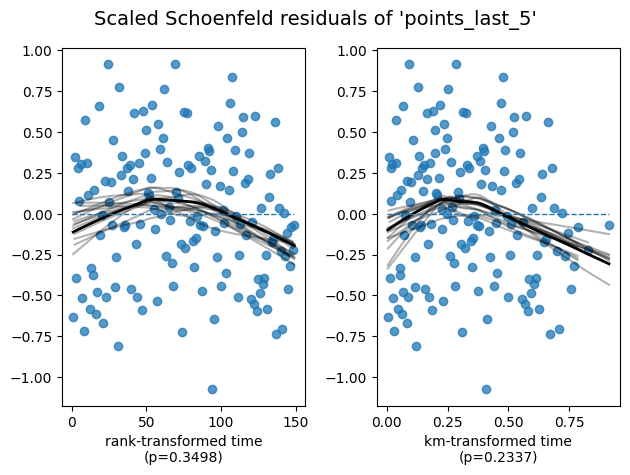

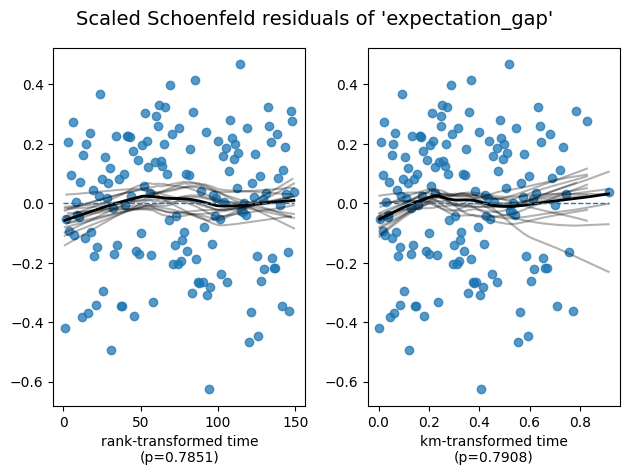

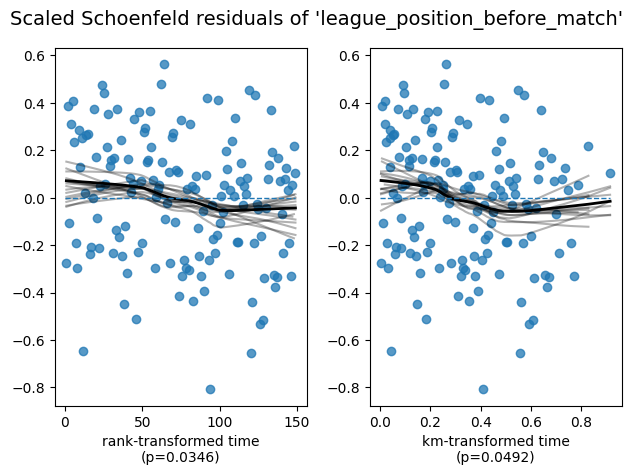

In [37]:
cph.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=True)

In [38]:
df_sorted = df.sort_values(['manager', 'team', 'manager_start_date', 'match_date']).copy()

# For each tenure, flag whether a sacking happens in the next 5 matches
df_sorted['matches_remaining_in_tenure'] = (
    df_sorted.groupby(['manager', 'team', 'manager_start_date']).cumcount(ascending=False)
)

# sacked_next_5 = 1 if this tenure ends in a sacking AND there are
# 4 or fewer matches left after this one (i.e. within the next 5)
df_sorted['sacked_next_5'] = (
    (df_sorted['event_observed'] == 1) & (df_sorted['matches_remaining_in_tenure'] <= 4)
).astype(int)

print(df_sorted['sacked_next_5'].value_counts())

sacked_next_5
0    15110
1      758
Name: count, dtype: int64


In [39]:
import statsmodels.api as sm

logit_df = df_sorted.dropna(subset=['points_last_5', 'expectation_gap', 'league_position_before_match']).copy()

X = logit_df[['points_last_5', 'expectation_gap', 'league_position_before_match']]
X = sm.add_constant(X)
y = logit_df['sacked_next_5']

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.183827
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          sacked_next_5   No. Observations:                14829
Model:                          Logit   Df Residuals:                    14825
Method:                           MLE   Df Model:                            3
Date:                Wed, 16 Sep 2026   Pseudo R-squ.:                 0.07171
Time:                        08:22:14   Log-Likelihood:                -2726.0
converged:                       True   LL-Null:                       -2936.6
Covariance Type:            nonrobust   LLR p-value:                 5.686e-91
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -1.9471      0.159    -12.234      0.000

In [40]:
# Get the season of each tenure's LAST match, so we can split by it
last_match_season = (
    df_sorted.groupby(['manager', 'team', 'manager_start_date'])['season']
    .last()
    .reset_index()
    .rename(columns={'season': 'final_season'})
)

survival_df = survival_df.merge(last_match_season, on=['manager', 'team', 'manager_start_date'], how='left')

print(survival_df['final_season'].value_counts().sort_index())

final_season
506      8
607     12
708     13
809     15
910     12
1011    11
1112    13
1213    13
1314    17
1415    11
1516    16
1617    12
1718    17
1819    11
1920     9
2021    11
2122    12
2223    19
2324    10
2425    11
2526    30
Name: count, dtype: int64


In [41]:
test_seasons = ['2324', '2425', '2526']

train_df = survival_df[~survival_df['final_season'].astype(str).isin(test_seasons)].copy()
test_df = survival_df[survival_df['final_season'].astype(str).isin(test_seasons)].copy()

print(f"Train: {train_df.shape[0]} tenures, {train_df['event_observed'].sum()} events")
print(f"Test: {test_df.shape[0]} tenures, {test_df['event_observed'].sum()} events")

Train: 232 tenures, 130 events
Test: 51 tenures, 22 events


In [42]:
from lifelines import CoxPHFitter

# Refit on TRAINING data only - this model has never seen the test seasons
train_cox_df = train_df.dropna(subset=['points_last_5', 'expectation_gap', 'league_position_before_match']).copy()
train_cox_df = train_cox_df[[
    'tenure_total_duration_days', 'event_observed',
    'points_last_5', 'expectation_gap', 'league_position_before_match'
]]

cph_train = CoxPHFitter()
cph_train.fit(train_cox_df, duration_col='tenure_total_duration_days', event_col='event_observed')

print(f"Trained on {train_cox_df.shape[0]} tenures")
cph_train.print_summary()

Trained on 222 tenures


<lifelines.CoxPHFitter: fitted with 222 total observations, 95 right-censored observations>
             duration col = 'tenure_total_duration_days'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 222
number of events observed = 127
   partial log-likelihood = -554.87
         time fit was run = 2026-09-16 08:22:14 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
points_last_5                -0.22      0.81      0.04           -0.30           -0.13                0.74                0.87
expectation_gap               0.01      1.01      0.02           -0.03            0.05                0.97                1.06
league_position_before_match -0.06      0.94      0.02           -0.11           -0.01                0.90                0.99

                              cmp to     z      p  -log2(p)
covariate                                                  
points_last_5                   0.00 -5.16 <0.005     21.96
expectation_gap                 0.00  0.68   0.50      1.00
league_position_before_match    0.00 -2.49   0.01      6.29
---
Concordance = 0.63
Partial AIC = 1115.74
log-likelihood ratio test = 39.66 on 3 df
-log2(p) of ll-ratio test = 26.24

In [43]:
from lifelines import CoxPHFitter

# Refit on TRAINING data only - this model has never seen the test seasons
train_cox_df = train_df.dropna(subset=['points_last_5', 'expectation_gap', 'league_position_before_match']).copy()
train_cox_df = train_cox_df[[
    'tenure_total_duration_days', 'event_observed',
    'points_last_5', 'expectation_gap', 'league_position_before_match'
]]

cph_train = CoxPHFitter()
cph_train.fit(train_cox_df, duration_col='tenure_total_duration_days', event_col='event_observed')

print(f"Trained on {train_cox_df.shape[0]} tenures")
cph_train.print_summary()

Trained on 222 tenures


<lifelines.CoxPHFitter: fitted with 222 total observations, 95 right-censored observations>
             duration col = 'tenure_total_duration_days'
                event col = 'event_observed'
      baseline estimation = breslow
   number of observations = 222
number of events observed = 127
   partial log-likelihood = -554.87
         time fit was run = 2026-09-16 08:22:14 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
points_last_5                -0.22      0.81      0.04           -0.30           -0.13                0.74                0.87
expectation_gap               0.01      1.01      0.02           -0.03            0.05                0.97                1.06
league_position_before_match -0.06      0.94      0.02           -0.11           -0.01                0.90                0.99

                              cmp to     z      p  -log2(p)
covariate                                                  
points_last_5                   0.00 -5.16 <0.005     21.96
expectation_gap                 0.00  0.68   0.50      1.00
league_position_before_match    0.00 -2.49   0.01      6.29
---
Concordance = 0.63
Partial AIC = 1115.74
log-likelihood ratio test = 39.66 on 3 df
-log2(p) of ll-ratio test = 26.24

In [44]:
test_cox_df = test_df.dropna(subset=['points_last_5', 'expectation_gap', 'league_position_before_match']).copy()
test_cox_df = test_cox_df[[
    'tenure_total_duration_days', 'event_observed',
    'points_last_5', 'expectation_gap', 'league_position_before_match'
]]

test_concordance = cph_train.score(test_cox_df, scoring_method='concordance_index')
print(f"Concordance on held-out test seasons: {test_concordance:.3f}")
print(f"(compare to training concordance: {cph_train.concordance_index_:.3f})")

Concordance on held-out test seasons: 0.667
(compare to training concordance: 0.630)


            avg_predicted_risk  actual_sacked_rate  n_tenures
risk_group                                                   
Low                   0.408386            0.294118         17
Medium                0.896555            0.294118         17
High                  2.172215            0.705882         17


/tmp/ipykernel_4024/4126392975.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = test_cox_df.groupby('risk_group').agg(


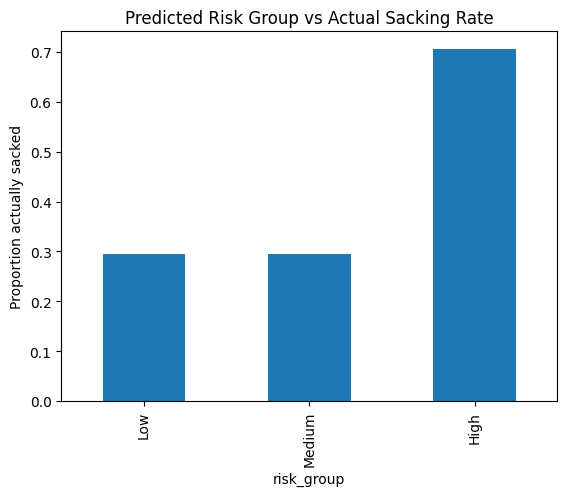

In [45]:
import numpy as np

# Get each test tenure's relative risk score from the trained model
test_cox_df['predicted_risk'] = cph_train.predict_partial_hazard(test_cox_df)

# Split into risk groups (Low/Medium/High) based on predicted risk
test_cox_df['risk_group'] = pd.qcut(test_cox_df['predicted_risk'], q=3, labels=['Low', 'Medium', 'High'])

# For each group: average predicted risk vs actual proportion sacked
calibration = test_cox_df.groupby('risk_group').agg(
    avg_predicted_risk=('predicted_risk', 'mean'),
    actual_sacked_rate=('event_observed', 'mean'),
    n_tenures=('event_observed', 'count')
)
print(calibration)

calibration['actual_sacked_rate'].plot(kind='bar', title='Predicted Risk Group vs Actual Sacking Rate')
plt.ylabel('Proportion actually sacked')
plt.show()

               avg_predicted_risk  actual_sacked_rate  n_tenures
risk_quintile                                                   
1 (Lowest)               0.314736            0.090909         11
2                        0.630643            0.500000         10
3                        0.875527            0.300000         10
4                        1.305911            0.500000         10
5 (Highest)              2.752875            0.800000         10


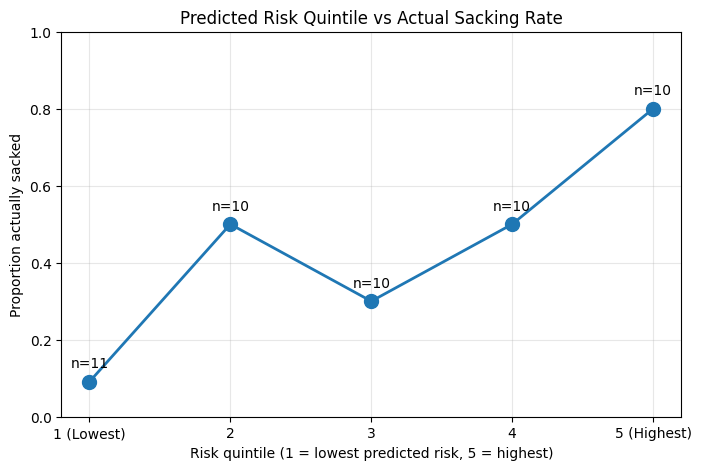

In [46]:
# Re-bin into 5 groups instead of 3 for finer resolution
test_cox_df['risk_quintile'] = pd.qcut(test_cox_df['predicted_risk'], q=5, labels=['1 (Lowest)', '2', '3', '4', '5 (Highest)'])

calibration_5 = test_cox_df.groupby('risk_quintile', observed=True).agg(
    avg_predicted_risk=('predicted_risk', 'mean'),
    actual_sacked_rate=('event_observed', 'mean'),
    n_tenures=('event_observed', 'count')
)
print(calibration_5)

plt.figure(figsize=(8, 5))
plt.plot(calibration_5.index, calibration_5['actual_sacked_rate'], marker='o', linewidth=2, markersize=10)
plt.title('Predicted Risk Quintile vs Actual Sacking Rate')
plt.xlabel('Risk quintile (1 = lowest predicted risk, 5 = highest)')
plt.ylabel('Proportion actually sacked')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
for i, (rate, n) in enumerate(zip(calibration_5['actual_sacked_rate'], calibration_5['n_tenures'])):
    plt.annotate(f'n={n}', (i, rate), textcoords="offset points", xytext=(0, 10), ha='center')
plt.show()